Analysis --> Feature Engineering --> Model --> Web app

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('german_credit_data.csv')

In [3]:
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [5]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [6]:
df.shape

(1000, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df['Job'].unique()

array([2, 1, 3, 0])

In [10]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.dropna().reset_index(drop=True)

In [13]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [14]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [15]:
df.drop(columns="Unnamed: 0", inplace=True)

In [16]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

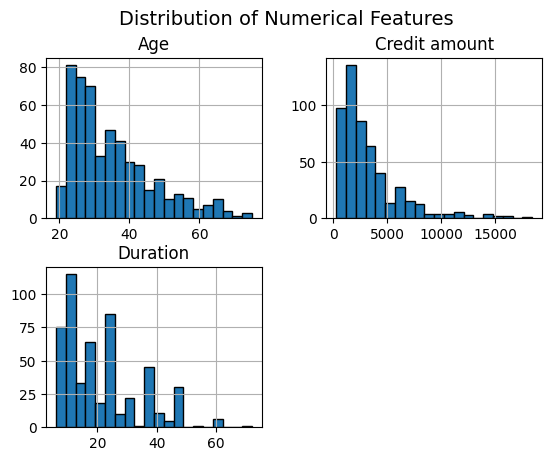

In [17]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.show()

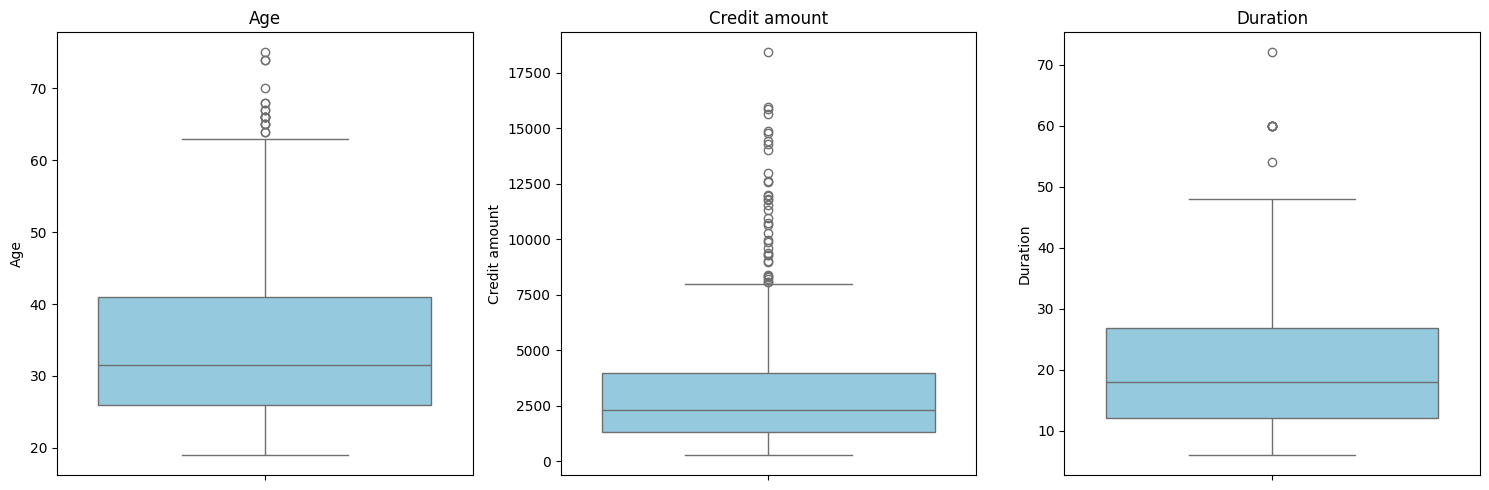

In [18]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
df.query('`Duration` >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [21]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

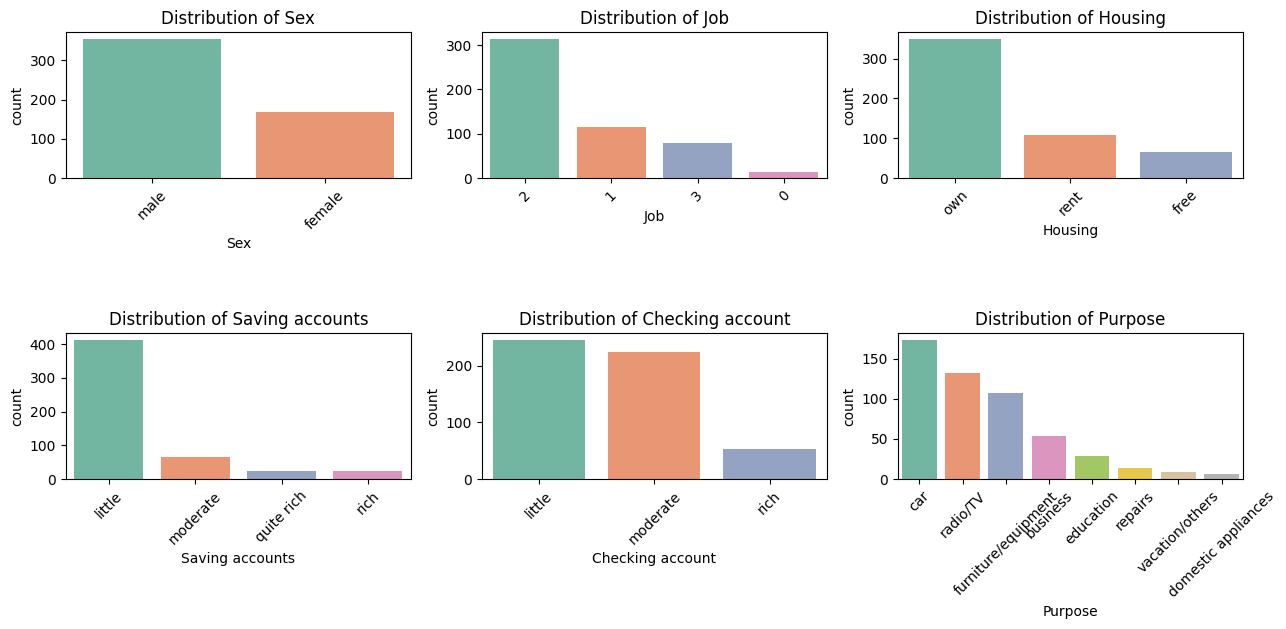

In [22]:
plt.figure(figsize=(13,8))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(
        data=df,
        x=col,
        palette='Set2',
        order=df[col].value_counts().index
    )
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
corr = df[['Age', 'Credit amount', 'Duration']].corr()

In [24]:
corr

,Age,Credit amount,Duration
Age,1.000000,0.082014,0.001549
Credit amount,0.082014,1.000000,0.613298
Duration,0.001549,0.613298,1.000000


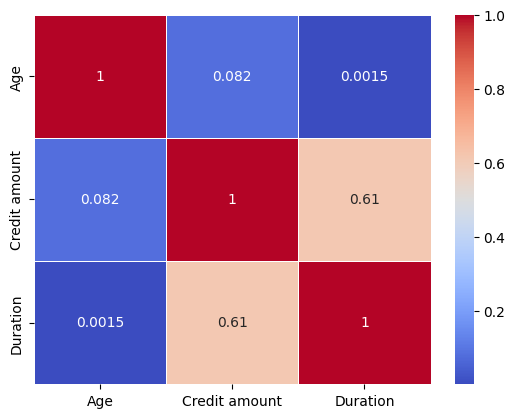

In [25]:
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            linewidths=0.5)
plt.show()

In [26]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [27]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [28]:
pd.pivot_table(df, 
               values='Credit amount', 
               index='Housing', 
               columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


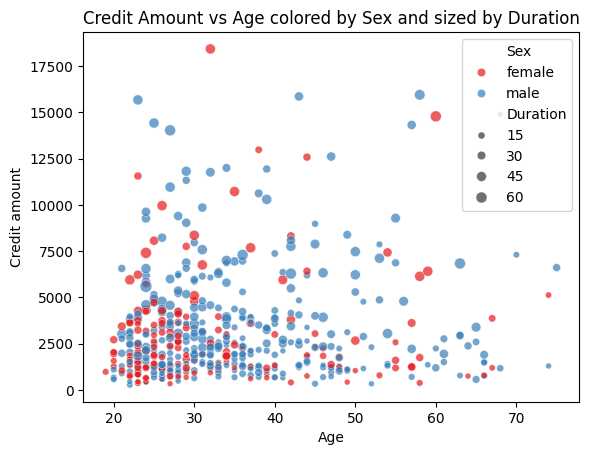

In [29]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Credit amount',
    hue='Sex',
    size='Duration',
    alpha=0.7,
    palette='Set1'
)

plt.title('Credit Amount vs Age colored by Sex and sized by Duration')
plt.show()

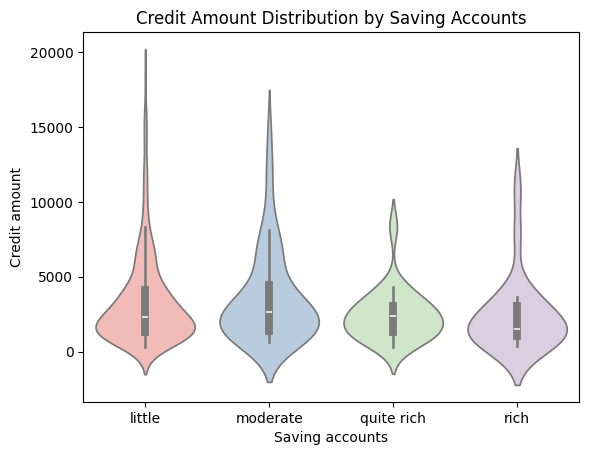

In [30]:
sns.violinplot(data = df,
               x = 'Saving accounts',
               y = 'Credit amount',
               palette = 'Pastel1')
plt.title('Credit Amount Distribution by Saving Accounts')
plt.show()

In [31]:
df.Risk.value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

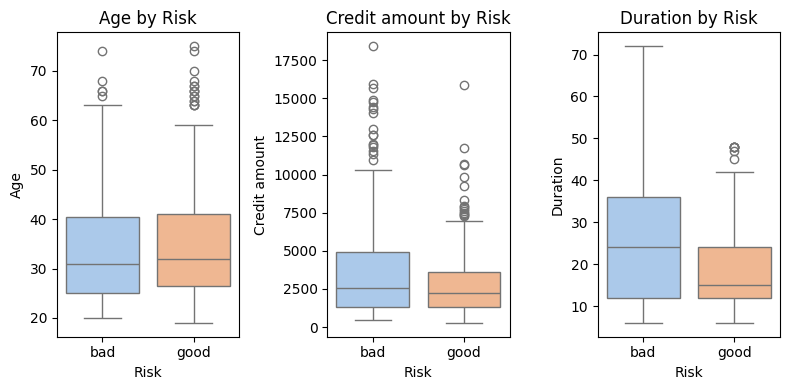

In [32]:
plt.figure(figsize=(8, 4))
for i, col in enumerate(['Age', 
                       'Credit amount', 
                       'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df,
                x='Risk',
                y=col,
                palette='pastel')
    plt.title(f'{col} by Risk')
    plt.tight_layout()
plt.show()

In [33]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [34]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [35]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

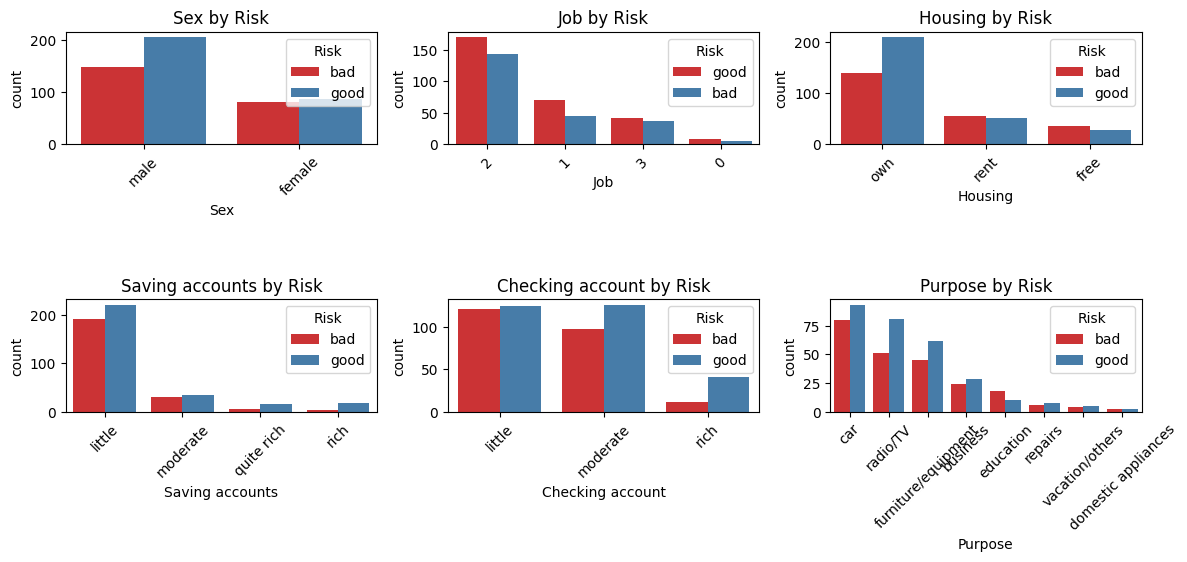

In [36]:
plt.figure(figsize=(12, 7))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(
        data=df,
        x=col,
        hue='Risk',
        palette='Set1',
        order=df[col].value_counts().index
    )
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
feartures = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Credit amount', 'Duration']

In [38]:
target = 'Risk'

In [39]:
df_model = df[feartures + [target]].copy()

In [40]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,radio/TV,5951,48,bad
1,45,male,2,free,little,little,furniture/equipment,7882,42,good
2,53,male,2,free,little,little,car,4870,24,bad
3,35,male,3,rent,little,moderate,car,6948,36,good
4,28,male,3,own,little,moderate,car,5234,30,bad


In [41]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [42]:
cat_cols = df_model.select_dtypes(include='object').columns.drop('Risk')

In [43]:
le_dict = {}

In [44]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [45]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [46]:
le_target = LabelEncoder()

In [47]:
target

'Risk'

In [48]:
df_model[target] = le_target.fit_transform(df_model[target])

In [49]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [50]:
joblib.dump(le_target, f"{target}_target_encoder.pkl")

['Risk_target_encoder.pkl']

In [51]:
df_model.head() 

,Age,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5,5951,48,0
1,45,1,2,0,0,0,4,7882,42,1
2,53,1,2,0,0,0,1,4870,24,0
3,35,1,3,2,0,1,1,6948,36,1
4,28,1,3,1,0,1,1,5234,30,0


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x = df_model.drop(target, axis=1)
y = df_model[target]

In [54]:
df['Saving accounts'].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [55]:
df['Checking account'].unique()

array(['moderate', 'little', 'rich'], dtype=object)

In [56]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Credit amount,Duration
0,22,0,2,1,0,1,5,5951,48
1,45,1,2,0,0,0,4,7882,42
2,53,1,2,0,0,0,1,4870,24
3,35,1,3,2,0,1,1,6948,36
4,28,1,3,1,0,1,1,5234,30
...,...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,5,1743,24
518,30,1,3,1,0,0,4,3959,36
519,40,1,3,1,0,0,1,3857,30
520,23,1,2,0,0,0,5,1845,45


In [57]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1)

In [59]:
x_train.shape

(417, 9)

In [60]:
x_test.shape

(105, 9)

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [62]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=1   # FIXED
    )

    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)

    return best_model, acc, grid.best_params_

In [63]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [64]:
best_dt, acc_dt, params_dt = train_model(
    dt,
    dt_param_grid,
    x_train,
    y_train,
    x_test,
    y_test
)

In [65]:
print('Decision Tree Accuracy', acc_dt)

Decision Tree Accuracy 0.6


In [66]:
print('Best parameters',params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [67]:
rf = RandomForestClassifier(random_state=1, 
                            class_weight='balanced', 
                            n_jobs=-1
                            )


In [68]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [69]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [70]:
print('random forest accuracy', acc_rf)

random forest accuracy 0.6285714285714286


In [71]:
print('best parameters', params_rf)

best parameters {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [72]:
et = ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [73]:
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [74]:
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [75]:
print('extra trees accuracy:', acc_et)

extra trees accuracy: 0.6571428571428571


In [76]:
print('Best params:', params_et)

Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [77]:
xgb = XGBClassifier(
    random_state=1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='logloss'
)


In [78]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

In [79]:
best_xgb, acc_xgb, params_xgb = train_model(
    xgb,
    xgb_param_grid,
    x_train,
    y_train,
    x_test,
    y_test
)

In [80]:
print("XGB accuracy:", acc_xgb)

XGB accuracy: 0.638095238095238


In [81]:
print('Best Params:', params_xgb)

Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


In [82]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1])

In [83]:
joblib.dump(best_et, 'extra_trees_credit_model.pkl')

['extra_trees_credit_model.pkl']